## Librerias

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulación Monte Carlo y su relación con la valuación de derivados

## Parte I. Teoría de simulación Monte Carlo
Se revisa el concepto, la intuición, el fundamento probabilístico y el algoritmo general.

**¿Qué es la simulación Monte Carlo?**

La simulación Monte Carlo es una técnica numérica utilizada para aproximar valores esperados, probabilidades, integrales o precios, cuando el cálculo exacto resulta difícil o imposible de obtener analíticamente.

La idea esencial es reemplazar un problema analítico por uno estadístico.

En muchos problemas queremos calcular una cantidad como:

$$
\theta = \mathbb{E}[g(X)],
$$

donde:

- $X$ es una variable aleatoria o un vector aleatorio,
- $g(X)$ es una función de interés,
- y $\theta$ es la cantidad que se desea estimar.

Si no es sencillo calcular esta esperanza mediante una fórmula cerrada o una integral explícita, entonces se puede proceder de la siguiente manera:

1. simular muchas observaciones independientes de $X$,
2. evaluar la función $g(X)$ en cada simulación,
3. promediar los resultados.

Ese promedio proporciona una aproximación de $\theta$.

**Interpretación intuitiva**

Monte Carlo se basa en la idea de que:

- una simulación individual representa un escenario posible,
- muchas simulaciones representan una colección de futuros posibles,
- y el promedio de esos resultados aproxima el comportamiento esperado del sistema.

En otras palabras, Monte Carlo convierte un problema teórico en un experimento computacional repetido muchas veces.

**¿Por qué funciona Monte Carlo?**

La justificación teórica del método proviene principalmente de dos resultados fundamentales de probabilidad:

1. **Ley de los Grandes Números**
2. **Teorema Central del Límite**

#### 2.1 Ley de los Grandes Números

Si $Y_1, Y_2, \dots, Y_n$ son variables aleatorias independientes e idénticamente distribuidas, con esperanza finita, entonces:

$$
\frac{1}{n}\sum_{i=1}^n Y_i \xrightarrow[n\to\infty]{} \mathbb{E}[Y]
$$

Es decir, el promedio muestral converge al valor esperado verdadero.

En Monte Carlo tomamos:

$$
Y_i = g(X_i),
$$

donde $X_1, X_2, \dots, X_n$ son simulaciones independientes de la variable aleatoria $X$.

Entonces el estimador Monte Carlo es:

$$
\hat{\theta}_n = \frac{1}{n}\sum_{i=1}^n g(X_i),
$$

y por la Ley de los Grandes Números:

$$
\hat{\theta}_n \to \mathbb{E}[g(X)] = \theta.
$$

#### 2.2 Teorema Central del Límite

Además, si la varianza de $g(X)$ es finita, entonces:

$$
\sqrt{n}\left(\hat{\theta}_n - \theta\right)\xrightarrow{d} N(0,\sigma^2),
$$

donde:

$$
\sigma^2 = \mathrm{Var}(g(X)).
$$

Esto implica que, para muestras grandes, el error de Monte Carlo se comporta aproximadamente como una normal con desviación estándar:

$$
\frac{\sigma}{\sqrt{n}}.
$$

Esta relación es muy importante porque muestra que el error disminuye a razón de:

$$
\mathcal{O}\left(\frac{1}{\sqrt{n}}\right).
$$

Esto significa que la convergencia de Monte Carlo es robusta, pero relativamente lenta.

### Forma general del estimador Monte Carlo

Supongamos que queremos estimar:

$$
\theta = \mathbb{E}[g(X)].
$$

Si generamos $n$ simulaciones independientes

$$
X_1, X_2, \dots, X_n,
$$

entonces el estimador Monte Carlo se define como:

$$
\hat{\theta}_n = \frac{1}{n}\sum_{i=1}^{n} g(X_i).
$$

### Propiedades del estimador

#### 1. Insesgadez

Si $g(X)$ tiene esperanza finita, entonces:

$$
\mathbb{E}[\hat{\theta}_n] = \theta.
$$

Es decir, en promedio, el estimador Monte Carlo da el valor correcto.

#### 2. Varianza

La varianza del estimador es:

$$
\mathrm{Var}(\hat{\theta}_n) = \frac{\mathrm{Var}(g(X))}{n}.
$$

Esto indica que aumentar el número de simulaciones reduce la varianza de la estimación.

#### 3. Error estándar

Si llamamos

$$
\sigma = \sqrt{\mathrm{Var}(g(X))},
$$

entonces el error estándar de la estimación es:

$$
\mathrm{SE}(\hat{\theta}_n) = \frac{\sigma}{\sqrt{n}}.
$$

#### 4. Intervalo de confianza aproximado

Para muestras grandes, puede construirse un intervalo de confianza del 95% como:

$$
\hat{\theta}_n \pm 1.96 \cdot \frac{s}{\sqrt{n}},
$$

donde $s$ es la desviación estándar muestral de los valores simulados $g(X_1), \dots, g(X_n)$.

### Algoritmo general de simulación Monte Carlo

El procedimiento general de Monte Carlo puede resumirse en los siguientes pasos.

**Paso 1.** Definir la cantidad de interés
Se identifica claramente qué se quiere calcular. Generalmente se trata de:

- una esperanza,
- una probabilidad,
- una integral,
- un payoff esperado,
- o el precio de un instrumento financiero.

**Paso 2.** Especificar el modelo probabilístico
Se debe conocer o asumir la distribución de la variable aleatoria o del proceso estocástico involucrado.

**Paso 3.** Generar simulaciones
Se generan muchas realizaciones independientes del fenómeno aleatorio.

**Paso 4.** Evaluar la función objetivo
En cada escenario simulado se calcula la cantidad relevante.

**Paso 5.** Promediar
Se obtiene el promedio muestral de los resultados simulados.

**Paso 6.** Cuantificar la precisión
Se calcula el error estándar y, si se desea, un intervalo de confianza.

**Idea clave**

Monte Carlo no reemplaza al modelo.

La simulación requiere que primero se especifique:

- qué variable aleatoria se está modelando,
- con qué distribución,
- con qué parámetros,
- y bajo qué supuestos.

Por ello, Monte Carlo reduce error numérico, pero no corrige errores de modelación.

### Tipos de problemas que puede resolver Monte Carlo

La simulación Monte Carlo se puede usar para resolver distintos tipos de problemas.

**Estimación de esperanzas**
Por ejemplo:

$$
\mathbb{E}[X], \quad \mathbb{E}[X^2], \quad \mathbb{E}[g(X)].
$$

**Estimación de probabilidades**
Una probabilidad puede escribirse como una esperanza de una variable indicadora:

$$
P(A) = \mathbb{E}[\mathbf{1}_A].
$$

Esto permite estimar probabilidades mediante simulación.

**Estimación de integrales**
Si $U \sim U(0,1)$, entonces:

$$
\mathbb{E}[f(U)] = \int_0^1 f(u)\,du.
$$

Por lo tanto, una integral puede verse como una esperanza y estimarse por Monte Carlo.

**Valuación de instrumentos financieros**
Muchos precios financieros tienen la forma:

$$
\text{Precio} = \text{descuento} \times \mathbb{E}[\text{Payoff}].
$$

Por ello, Monte Carlo es una herramienta natural para valuar derivados.

## Parte II. Ejemplos sencillos
Se implementan ejemplos básicos para entender cómo estimar esperanzas y probabilidades por simulación.


### Primer ejemplo teórico: estimar una esperanza

Considérese una variable aleatoria uniforme en el intervalo $(0,1)$:

$$
X \sim U(0,1).
$$

Queremos estimar:

$$
\mathbb{E}[X^2].
$$

Sabemos analíticamente que:

$$
\mathbb{E}[X^2] = \int_0^1 x^2 \, dx = \frac{1}{3}.
$$

Sin embargo, desde el punto de vista de Monte Carlo, no necesitamos resolver la integral. Basta con:

1. generar muchas simulaciones de $X$,
2. elevar cada una al cuadrado,
3. promediar.

Es decir, si simulamos $X_1, \dots, X_n$, estimamos mediante:

$$
\hat{\theta}_n = \frac{1}{n}\sum_{i=1}^n X_i^2.
$$

A medida que $n$ crece, este promedio se acerca a $\frac{1}{3}$.

In [2]:
# Fijamos una semilla para hacer reproducible el experimento
np.random.seed(42)

In [3]:
# Número de simulaciones
n = 100000

# Simulación de X ~ U(0,1)
X = np.random.uniform(low=0.0, high=1.0, size=n)

# Evaluamos la función g(X) = X^2
Y = X**2

# Estimación Monte Carlo
estimacion_mc = np.mean(Y)

# Valor exacto
valor_exacto = 1/3

print("Estimación Monte Carlo:", estimacion_mc)
print("Valor exacto         :", valor_exacto)
print("Error absoluto       :", abs(estimacion_mc - valor_exacto))

Estimación Monte Carlo: 0.3326284706176863
Valor exacto         : 0.3333333333333333
Error absoluto       : 0.0007048627156470144


En el ejemplo anterior, Monte Carlo aproxima la esperanza de $X^2$ mediante el promedio de muchos valores simulados de la forma:

$$
X_1^2, X_2^2, \dots, X_n^2.
$$

La lógica es muy importante:

- primero se simula la variable aleatoria,
- después se aplica la función de interés,
- y finalmente se toma el promedio.

Este patrón se repetirá más adelante en la valuación de derivados.

**¿Qué representa el error?**

La diferencia entre la estimación Monte Carlo y el valor exacto se debe al error muestral.

Aunque el método converge, cada simulación usa una muestra finita, y por ello la respuesta cambia ligeramente de una corrida a otra.

Sin embargo, si el número de simulaciones crece, el error tiende a disminuir.

In [4]:
# Desviación estándar muestral de los valores Y = X^2
desv_muestral = np.std(Y, ddof=1)

# Error estándar de la estimación Monte Carlo
error_estandar = desv_muestral / np.sqrt(n)

# Intervalo de confianza al 95%
ic_inf = estimacion_mc - 1.96 * error_estandar
ic_sup = estimacion_mc + 1.96 * error_estandar

print("Desviación estándar muestral:", desv_muestral)
print("Error estándar              :", error_estandar)
print("IC 95%                      :", (ic_inf, ic_sup))

Desviación estándar muestral: 0.29741161017842893
Error estándar              : 0.0009404980907419523
IC 95%                      : (np.float64(0.33078509435983205), np.float64(0.33447184687554055))


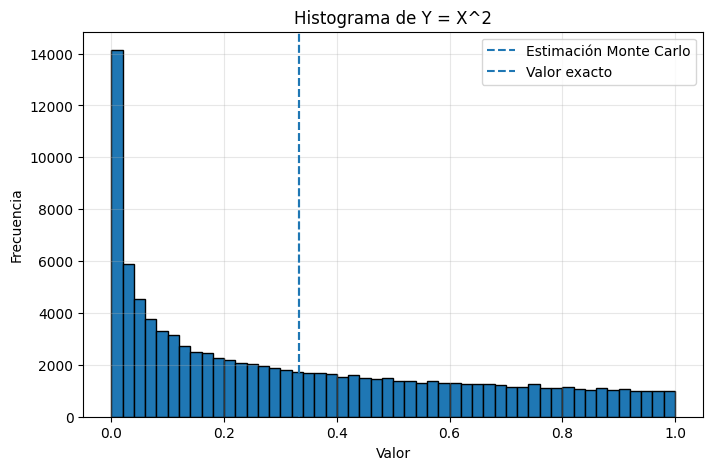

In [5]:
plt.figure(figsize=(8,5))
plt.hist(Y, bins=50, edgecolor="black")
plt.axvline(estimacion_mc, linestyle="--", label="Estimación Monte Carlo")
plt.axvline(valor_exacto, linestyle="--", label="Valor exacto")
plt.title("Histograma de Y = X^2")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Segundo ejemplo teórico: estimar una probabilidad

Ahora queremos estimar la probabilidad:

$$
P(Z > 1.5),
$$

donde:

$$
Z \sim N(0,1).
$$

La idea central es convertir esta probabilidad en una esperanza.

Definimos la variable indicadora:

$$
I = \mathbf{1}_{\{Z > 1.5\}}.
$$

Entonces:

$$
I =
\begin{cases}
1, & \text{si } Z > 1.5,\\
0, & \text{si } Z \le 1.5.
\end{cases}
$$

Y se cumple que:

$$
\mathbb{E}[I] = P(Z > 1.5).
$$

Por lo tanto, si simulamos muchos valores de $Z$ y calculamos la variable indicadora en cada caso, el promedio de esos unos y ceros aproxima la probabilidad buscada.

In [6]:
# Número de simulaciones
n = 100000

# Simulamos Z ~ N(0,1)
Z = np.random.normal(loc=0.0, scale=1.0, size=n)

# Variable indicadora
I = (Z > 1.5).astype(int)

# Estimación Monte Carlo de la probabilidad
prob_mc = np.mean(I)

print("Estimación Monte Carlo de P(Z > 1.5):", prob_mc)

Estimación Monte Carlo de P(Z > 1.5): 0.06685


### Convergencia de Monte Carlo

Una propiedad esencial de Monte Carlo es que mejora a medida que se incrementa el número de simulaciones.

En términos matemáticos, esto se debe a que:

$$
\hat{\theta}_n \to \theta
$$

cuando $n \to \infty$.

Sin embargo, la velocidad de convergencia es relativamente lenta, ya que el error disminuye como:

$$
\frac{1}{\sqrt{n}}.
$$

Esto tiene una consecuencia importante:

- si queremos reducir el error a la mitad,
- necesitamos aproximadamente cuadruplicar el número de simulaciones.

Por ello, en aplicaciones reales se suelen utilizar miles, decenas de miles o incluso millones de simulaciones.

In [7]:
ns = [10, 100, 1000, 10000, 100000]
estimaciones = []

for n in ns:
    X_temp = np.random.uniform(0, 1, size=n)
    Y_temp = X_temp**2
    estimaciones.append(np.mean(Y_temp))

for n, est in zip(ns, estimaciones):
    print(f"n = {n:>6} -> estimación = {est:.6f}")

n =     10 -> estimación = 0.247432
n =    100 -> estimación = 0.312133
n =   1000 -> estimación = 0.330197
n =  10000 -> estimación = 0.335370
n = 100000 -> estimación = 0.333327


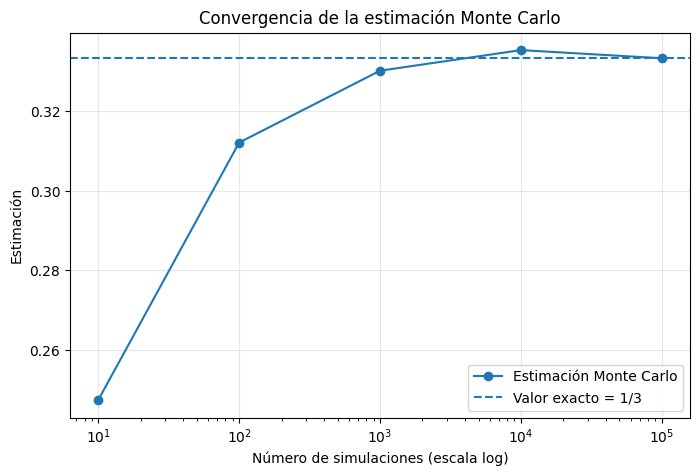

In [8]:
plt.figure(figsize=(8,5))
plt.plot(ns, estimaciones, marker='o', label='Estimación Monte Carlo')
plt.axhline(1/3, linestyle='--', label='Valor exacto = 1/3')
plt.xscale('log')
plt.title("Convergencia de la estimación Monte Carlo")
plt.xlabel("Número de simulaciones (escala log)")
plt.ylabel("Estimación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Ventajas**

1. Flexibilidad
Monte Carlo puede aplicarse a una amplia variedad de problemas.

2. Facilidad conceptual
La lógica del método es sencilla: simular, evaluar, promediar.

3. Utilidad en alta dimensión
En problemas de muchas variables, Monte Carlo suele ser más manejable que otros métodos numéricos.

4. Aplicación natural a derivados complejos
Cuando el payoff depende de trayectorias, barreras, promedios o múltiples fuentes de riesgo, Monte Carlo es especialmente útil.

**Limitaciones**

1. Convergencia lenta
El error disminuye a razón de $1/\sqrt{n}$.

2. Dependencia del modelo
Si el modelo probabilístico está mal especificado, el resultado también estará mal.

3. Costo computacional
Para alta precisión se requieren muchas simulaciones.

4. Dependencia del generador aleatorio
La calidad de los números pseudoaleatorios influye en la simulación.

**¿Por qué Monte Carlo es importante en derivados?**

En finanzas, muchos derivados se valoran como el valor presente de un payoff esperado bajo la medida neutral al riesgo.

En términos generales, si un derivado paga en el tiempo $T$ una cantidad aleatoria llamada `Payoff`, su precio en el tiempo 0 es:

$$
V_0 = e^{-rT}\mathbb{E}^{\mathbb{Q}}[\text{Payoff}],
$$

donde:

- $V_0$ es el precio hoy,
- $r$ es la tasa libre de riesgo,
- $T$ es el tiempo al vencimiento,
- $\mathbb{Q}$ es la medida neutral al riesgo.

Esta fórmula es extremadamente importante, porque muestra que valuar un derivado es, en esencia, calcular una esperanza.

Y justamente Monte Carlo está diseñado para aproximar esperanzas.

**Idea central en derivados**

La lógica de Monte Carlo en derivados es:

1. simular muchos escenarios del subyacente,
2. calcular el payoff en cada escenario,
3. promediar los payoffs,
4. descontar ese promedio al presente.

En el contexto de derivados, cada simulación representa un posible estado futuro del mercado.

Por ejemplo, en una opción sobre una acción, cada simulación puede representar un posible valor futuro del precio de la acción al vencimiento.

A partir de cada escenario simulado se calcula el payoff del derivado.

Después:

- si el derivado gana mucho en ciertos escenarios y poco en otros,
- Monte Carlo captura esa variabilidad,
- y el promedio descontado resume el valor esperado del contrato.

Monte Carlo no "adivina" el precio del derivado.

Lo que hace es aproximar de manera numérica una esperanza bajo un modelo probabilístico y bajo la medida neutral al riesgo.

Por ello, su validez depende tanto del método de simulación como del modelo financiero utilizado.